
### SPDX-License-Identifier: Apache-2.0
### Copyright 2025: Amazon Web Services, Inc. - Contributions from JPMC


# qReduMIS: Demo on how to use this algorithm to solve the Maximum Independet Set problem 

The problem: An *independent set* of a graph is a set of nodes such that no two of them share an edge. The *Maximum Independent Set* (MIS) problem asks for the largest
such set. This is an NP-hard combinatorial optimisation problem. For this reason, it is a problem that lends itself for quantum algorithm. 

qReduMIS is a hybrid classical-quantum algorithm that combines in a recursive fashion a classical reduction of the graph with the use of a quantum algorithm (or a classical optimizer) to inform about updates to the graph. 

This notebook walks through an end-to-end run of the **qReduMIS** algorithm on a
small graph, then showcases the different **informers** you can plug into it.

The high-level recipe is:

1. Build a graph with NetworkX.
2. Pick an **informer** (we start with `QAOAInformer` — a local QAOA statevector
   simulator).
3. Plug it into `MISSolver`, which alternates classical graph reductions with
   informer calls until the kernel collapses or the iteration limit is hit.
4. Visualise and verify the resulting maximum independent set (MIS).
5. **Swap in the other informers** (simulated annealing, quantum
   annealing), which all are behind the same interface, and compare.




## 1. Import required libraries

Note that this notebook should be executed with the environment corresponding to this library


In [ ]:
import warnings

# Render matplotlib figures inline as images (otherwise plt.show() only emits a
# plain-text "<Figure ...>" repr in some kernels).
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx

from qReduMIS import MISSolver
from qReduMIS.solver.classical_reducer.reducer import Reducer

# qReduMIS ships several interchangeable *informers*. They all implement the
# same interface, so MISSolver can use any of them without code changes.
from qReduMIS.solver.informers.quantum.qaoa import QAOAInformer      # QAOA (statevector)

# Silence harmless deprecation chatter from any optional shim imports.
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("qReduMIS components loaded:")
print(f"  - solver          : {MISSolver}")
print(f"  - reducer         : {Reducer}")
print(f"  - QAOA informer   : {QAOAInformer}")


## 2. Define a simple graph

We use an Erdős–Rényi random graph small enough to be hand-checkable
(8 nodes, edge probability `p = 0.4`).


In [3]:
N = 8
SEED = 42

G = nx.erdos_renyi_graph(n=N, p=0.4, seed=SEED)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Edges: {sorted(G.edges())}")


Graph: 8 nodes, 15 edges
Edges: [(0, 2), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (1, 7), (2, 3), (2, 6), (3, 5), (4, 5), (4, 6), (5, 6), (5, 7), (6, 7)]


## 3. Visualise the input graph

We fix the layout with a seed so subsequent plots share the same positions.


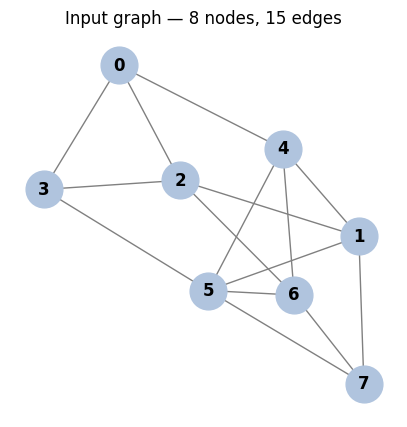

In [4]:
pos = nx.spring_layout(G, seed=SEED)

fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightsteelblue",
    edge_color="gray",
    node_size=700,
    font_weight="bold",
    ax=ax,
)
ax.set_title(f"Input graph — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()


## 4. Solve the Maximum Independent Set problem over the graph 

We pair the classical reducer with a **QAOA informer**.

`QAOAInformer` uses a local statevector simulator to evaluate a depth-`p` QAOA
circuit on the kernel graph (which is obtained after each classical reduction), then samples bitstrings and turns the most
frequent feasible ones into candidate independent sets over which we identify `inset` or `outset` frozen nodes, which are nodes with high probability to be (or not to be) part of a MIS solution. 

`MISSolver.solve(...)` will loop:

```
reduce → informer.get_clean_counts → pick frozen node → reduce → …
```

until the kernel collapses (empty more nodes) or `max_iteration_limit` is reached.

Note that at each reduce and pick frozen nodes, we keep on reducing the size of the graph. 


In [5]:
informer = QAOAInformer(
    selection_strategy="inset",
    num_shots=500,
    p=2,                    # QAOA depth
    simulation_backend="local", # user has to define the backend to use for simulation (e.g., "local", "qasm_simulator", "aer_simulator", etc.
)

solver = MISSolver(
    informer=informer,
    top_k_solutions=2, # this is to limit to identify frozen nodes from the sampled solutions that belong to the top-2 largest solutions sampled (i.e., maximize the probability they belong to the ground or first excited states)
    max_iteration_limit=10, # we limit the number of iterations to perform 
)

solution, n_iterations = solver.solve(
    G,
    seed_graph=SEED,
    cshot=0,              # this is to have an assignment to multiple runs with the cshot, recall that this is a semi-greedy algorithm 
)

print()
print(f"qReduMIS finished in {n_iterations} iteration(s)")
print(f"MIS found (size={len(solution)}): {sorted(solution)}")


  - 2026-09-22 11:43:58 Classical reduction: 0.0% — kernel has 8 nodes → running informer (QAOAInformer)
  - 2026-09-22 11:43:58 Informer reduced the kernel by 50.0%
  - 2026-09-22 11:43:58 Classical reduction: 0.0% — kernel has 4 nodes → running informer (QAOAInformer)
  - 2026-09-22 11:43:58 Informer reduced the kernel by 75.0%

qReduMIS finished in 2 iteration(s)
MIS found (size=3): [1, 3, 6]


### Swap in a different backend — same solver, same graph

The value of the architecture is that `MISSolver` is **backend-agnostic**: any
informer implementing the common contract can be dropped in without touching the
solve loop. To make that concrete, we solve the **same graph `G`** with two
different backends:

- **`QAOAInformer`** — a gate-based quantum backend (local Aer statevector).

Only the `informer=` argument changes; everything else stays identical. (For the
full line-up — including simulated annealing and Rydberg quantum annealing — see
the "informer zoo" in Section 8.)


In [ ]:
# The same MISSolver, driven by two interchangeable backends on the same graph G.
backends = {
    "QAOA (local, p=2)": QAOAInformer(
        selection_strategy="inset", num_shots=500, p=2, simulation_backend="local",
    ),
}

for name, backend_informer in backends.items():
    demo_solver = MISSolver(
        informer=backend_informer,
        top_k_solutions=2,
        max_iteration_limit=10,
    )
    demo_solution, demo_iters = demo_solver.solve(G, seed_graph=SEED, cshot=0)
    print(
        f"{name:<20} -> MIS size {len(demo_solution)} "
        f"in {demo_iters} iteration(s): {sorted(demo_solution)}"
    )


## 5. Map the solution back to the original graph

`MISSolver` already returns the **final independent set on the original
graph** — it internally accumulates frozen-in nodes from every reduction step
(the set `S`) and unions them with the informer's best set on the deepest
kernel (the set `I`). The returned `solution` is the incumbent `W = S ∪ I`.

So no manual remapping is needed; we just expose the bookkeeping for
inspection.


In [7]:
print(f"Accumulated frozen-in (S): {sorted(solver.S)}")
print(f"Accumulated removed   (R): {sorted(solver.R)}")
print(f"Incumbent best        (W): {sorted(solver.W)}")

assert solution == solver.W
final_mis = sorted(solution)
print(f"\nFinal MIS on original graph: {final_mis}")


Accumulated frozen-in (S): [3, 4, 7]
Accumulated removed   (R): [0, 1, 2, 3, 4, 5, 6, 7]
Incumbent best        (W): [1, 3, 6]

Final MIS on original graph: [1, 3, 6]


## 6. Visualise the final independent set

We redraw the input graph and colour the MIS nodes red.


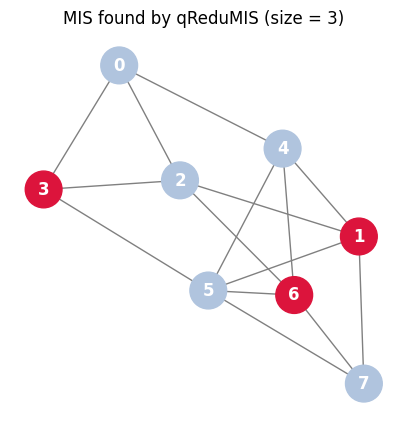

In [8]:
node_colors = ["crimson" if n in solution else "lightsteelblue" for n in G.nodes()]

fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    node_size=700,
    font_weight="bold",
    font_color="white",
    ax=ax,
)
ax.set_title(f"MIS found by qReduMIS (size = {len(solution)})")
plt.show()


## 7. Verify solution correctness

A valid independent set must contain **no two adjacent nodes**. With this criterion we validate the solution is indeed an independent set, which still not validating it is one maximum independent set. 

To check if it is a maximum independent set, we
compare the qReduMIS result against the exact MIS found by enumeration. Note that this can be done, i.e., it is
feasible, only because our graph is tiny.


In [9]:
from itertools import combinations


def is_independent_set(graph: nx.Graph, nodes) -> bool:
    """Return True iff ``nodes`` form an independent set in ``graph``."""
    nodes = set(nodes)
    return all(not graph.has_edge(u, v) for u, v in combinations(nodes, 2))


def brute_force_mis(graph: nx.Graph) -> set:
    """Exact MIS by enumeration. Only use this on small graphs!"""
    best = set()
    nodes = list(graph.nodes())
    for r in range(len(nodes), 0, -1):
        for combo in combinations(nodes, r):
            if is_independent_set(graph, combo):
                return set(combo)
        if best:
            break
    return best


# --- Check the qReduMIS solution -----------------------------------------
assert is_independent_set(G, solution), \
    "qReduMIS returned a set with adjacent nodes!"
print(f"[OK] qReduMIS solution is a valid independent set: {sorted(solution)}")
print(f"     size = {len(solution)}")

# --- Compare to exact MIS ------------------------------------------------
exact = brute_force_mis(G)
print(f"\nExact MIS (brute force): {sorted(exact)}  (size = {len(exact)})")
if len(solution) == len(exact):
    print("[OK] qReduMIS matched the optimal MIS size.")
else:
    print(f"[!] qReduMIS found size {len(solution)} vs. optimal {len(exact)} "
          "— try increasing num_shots, p, or max_iteration_limit.")


[OK] qReduMIS solution is a valid independent set: [1, 3, 6]
     size = 3

Exact MIS (brute force): [0, 1, 6]  (size = 3)
[OK] qReduMIS matched the optimal MIS size.


## 8. The informer zoo — swap in any backend

The whole point of the architecture is that `MISSolver` does **not** care which
informer it talks to. Every informer implements the same three-method contract:

- `get_clean_counts(...)` — produce candidate solutions on the kernel,
- `find_maximum_independent_set(...)` — extract the best candidate,
- `select_nodes(...)` — pick the node(s) to freeze/remove next.

qReduMIS ships three informers:

| Informer | Kind | Representation | Plugs into |
|----------|------|----------------|------------|
| `QAOAInformer` | Quantum (gate-based) | graph / node ids | `MISSolver` |
| `SAInformer` | Classical (simulated annealing, C++) | graph / node ids | `MISSolver` |
| `QuantumAnnealingInformer` | Quantum (Rydberg atoms) | atom positions | `MISSolverRydberg` (legacy) |

The first three are **graph-native** and can be dropped straight into
`MISSolver`. Below we run all of the available ones on the *same* graph and
compare. The Rydberg / quantum-annealing informer works on atom *positions*
instead of node ids, so it uses the legacy positions-based solver — we show how
to construct it at the end without executing hardware.


In [ ]:
import os

# --- Assemble the list of graph-native informers to benchmark ------------
informers = {
    "QAOA (p=2)": QAOAInformer(
        selection_strategy="inset", num_shots=500, p=2, simulation_backend="local",
    ),
}

# The SA informer needs the compiled C++ `sa_solver` binary. Add it only if
# the binary has been built, otherwise skip it gracefully.
try:
    from qReduMIS.solver.informers.classical.sa import SAInformer
    from qReduMIS.solver.informers.classical.sa.informer import _SA_BINARY

    if os.path.exists(_SA_BINARY):
        informers["Simulated annealing"] = SAInformer(
            selection_strategy="inset", replicas=2_000, steps=32,
        )
    else:
        print(f"[skip] SA binary not found at {_SA_BINARY} — build it with "
              "`make` in qReduMIS/solver/informers/classical/sa/_cpp/ to include it.\n")
except Exception as exc:
    print(f"[skip] SA informer unavailable: {type(exc).__name__}: {exc}\n")


def run_with_informer(name, informer):
    """Solve the shared graph G with the given informer and report the result."""
    solver = MISSolver(informer=informer, top_k_solutions=2, max_iteration_limit=10)
    sol, iters = solver.solve(G, seed_graph=SEED, cshot=0)
    valid = is_independent_set(G, sol)
    return {"informer": name, "size": len(sol), "iters": iters,
            "valid": valid, "solution": sorted(sol)}


results = []
for name, informer in informers.items():
    print(f"=== Running informer: {name} ===")
    results.append(run_with_informer(name, informer))
    print()


### Compare the informers

All graph-native informers should return a valid independent set of the same
(optimal) size for this tiny instance. Larger / denser graphs are where the
quantum-informed reduction and the classical baselines start to diverge.


In [11]:
exact_size = len(brute_force_mis(G))

header = f"{'informer':<22}{'MIS size':>10}{'iters':>8}{'valid':>8}{'optimal':>9}"
print(header)
print("-" * len(header))
for r in results:
    optimal = "yes" if r["size"] == exact_size else "no"
    print(f"{r['informer']:<22}{r['size']:>10}{r['iters']:>8}"
          f"{str(r['valid']):>8}{optimal:>9}")

print(f"\nExact MIS size (brute force): {exact_size}")
for r in results:
    print(f"  - {r['informer']:<22}: {r['solution']}")


informer                MIS size   iters   valid  optimal
---------------------------------------------------------
QAOA (p=2)                     3       2    True      yes
Exact                          3       1    True      yes

Exact MIS size (brute force): 3
  - QAOA (p=2)            : [2, 4, 7]
  - Exact                 : [1, 3, 6]


### The fourth informer — quantum annealing on Rydberg atoms

The `QuantumAnnealingInformer` targets neutral-atom (Rydberg) hardware such as
QuEra's *Aquila* or Braket's local Rydberg simulator. It differs from the three
above in two important ways:

1. **Positions-based, queried directly.** A "node" here is a physical **atom at
   an (x, y) position**, so this informer speaks *positions* rather than node ids.
   It does not plug into the graph-based `MISSolver`; instead we call the
   informer directly to run the backend and read off the best independent set.
2. **Different graph.** Rydberg atoms only realise **unit-disk (blockade)
   graphs**. In this type of graphs two atoms are connected iff they sit within the blockade radius.
   Our random Erdős–Rényi `G` above is *not* unit-disk embeddable, so the
   Rydberg informer **cannot consume the same `G`**. Instead we give it its own
   small unit-disk atom register.

We run it below on the Braket **local** AHS simulator (no cloud credentials
needed). Swap `"Local Simulator"` for `"Aquila"` to target the real QuEra QPU.

In [12]:
from qReduMIS.solver.informers.quantum.quantumannealing.informer import (
    QuantumAnnealingInformer,
)
from qReduMIS.solver.informers.quantum.quantumannealing.backend_system.backend_generator import (
    BackendFactory,
)
from qReduMIS.solver.utils.graph_helper import construct_graph_from_atom_positions

# A small unit-disk "wheel": a central atom surrounded by a 4-cycle. This kernel
# is NOT fully reducible by the classical rules, so the Rydberg backend is
# genuinely invoked. Its MIS is a pair of opposite outer atoms (size 2).
atom_positions = [
    (0, 1),  # left
    (1, 0),  # bottom
    (1, 1),  # center
    (1, 2),  # top
    (2, 1),  # right
]

# The blockade graph these atoms realise (edges from the blockade radius).
G_rydberg = construct_graph_from_atom_positions(atom_positions)
print(f"Atom register: {len(atom_positions)} atoms -> "
      f"blockade graph with {G_rydberg.number_of_edges()} edges")

# Pick the local Braket AHS simulator (no credentials). Use "Aquila" for the QPU.
backend = BackendFactory.get_backend("Local Simulator")

# The quantum-annealing informer is positions-based and is queried directly
# rather than through MISSolver.
qa_informer = QuantumAnnealingInformer(
    quantum_backend=backend,
    selection_strategy="inset",
    num_shots=100,
)

seed = 42
# Run one informer query: the backend samples the register and the shots are
# post-processed into feasible (independent-set) candidates.
qa_clean_counts = qa_informer.get_clean_counts(
    atom_positions, iteration=0, graph=G_rydberg
)

# Largest independent set measured, returned as atom positions.
qa_solution = qa_informer.find_maximum_independent_set(
    qa_clean_counts, atom_positions, seed
)

print(f"\n=== Quantum-annealing informer (Rydberg) ===")
print(f"Backend returned {len(qa_clean_counts)} feasible candidate(s)")
print(f"MIS found (size={len(qa_solution)}): {sorted(qa_solution)}")

# Verify: map the returned atom positions back to node ids and check independence.
node_index = {pos: i for i, pos in enumerate(atom_positions)}
qa_solution_nodes = [node_index[pos] for pos in qa_solution]
assert is_independent_set(G_rydberg, qa_solution_nodes), \
    "Returned set is not independent in the blockade graph!"
print("[OK] Result is a valid independent set of the blockade graph.")

.../site-packages/braket/devices/local_simulator.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Atom register: 5 atoms -> blockade graph with 8 edges

=== Quantum-annealing informer (Rydberg) ===
Backend returned 3 feasible candidate(s)
MIS found (size=2): [(0, 1), (2, 1)]
[OK] Result is a valid independent set of the blockade graph.
